# Project link
https://heart-disease-prediction-t3za.onrender.com

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,confusion_matrix,classification_report)

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [2]:
columns = ['age','sex','cp','trestbps','chol','fbs','restecg','thalach','exang','oldpeak','slope','ca','thal','target']

In [3]:
df = pd.read_csv("processed.cleveland.data",names=columns)

In [4]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [5]:
df.shape

(303, 14)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        303 non-null    str    
 12  thal      303 non-null    str    
 13  target    303 non-null    int64  
dtypes: float64(11), int64(1), str(2)
memory usage: 33.3 KB


In [7]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.937294
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,1.228536
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,4.000000


In [8]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [9]:
df.replace('?', np.nan, inplace=True)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,45.0,1.0,1.0,110.0,264.0,0.0,0.0,132.0,0.0,1.2,2.0,0.0,7.0,1
299,68.0,1.0,4.0,144.0,193.0,1.0,0.0,141.0,0.0,3.4,2.0,2.0,7.0,2
300,57.0,1.0,4.0,130.0,131.0,0.0,0.0,115.0,1.0,1.2,2.0,1.0,7.0,3
301,57.0,0.0,2.0,130.0,236.0,0.0,2.0,174.0,0.0,0.0,2.0,1.0,3.0,1


In [10]:
df = df.apply(pd.to_numeric)

In [11]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

In [12]:
imputer = SimpleImputer(strategy='median')
df = pd.DataFrame(imputer.fit_transform(df),columns=df.columns)

In [13]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [14]:
df['target'] = df['target'].apply(lambda x: 0 if x==0 else 1)

In [15]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [16]:
df['target'].value_counts()

target
0    164
1    139
Name: count, dtype: int64

0-> No Disease


1-> Disease

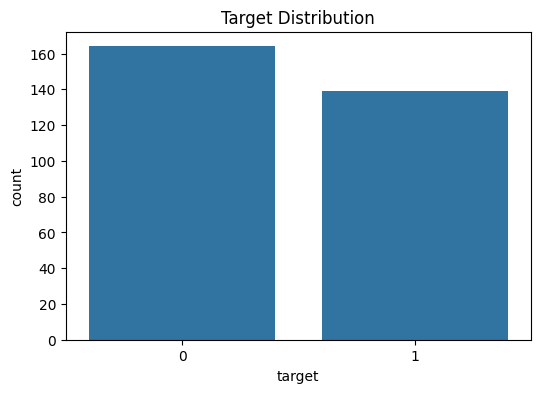

In [17]:
plt.figure(figsize=(6,4))

sns.countplot(x='target',data=df)
plt.title("Target Distribution")
plt.show()

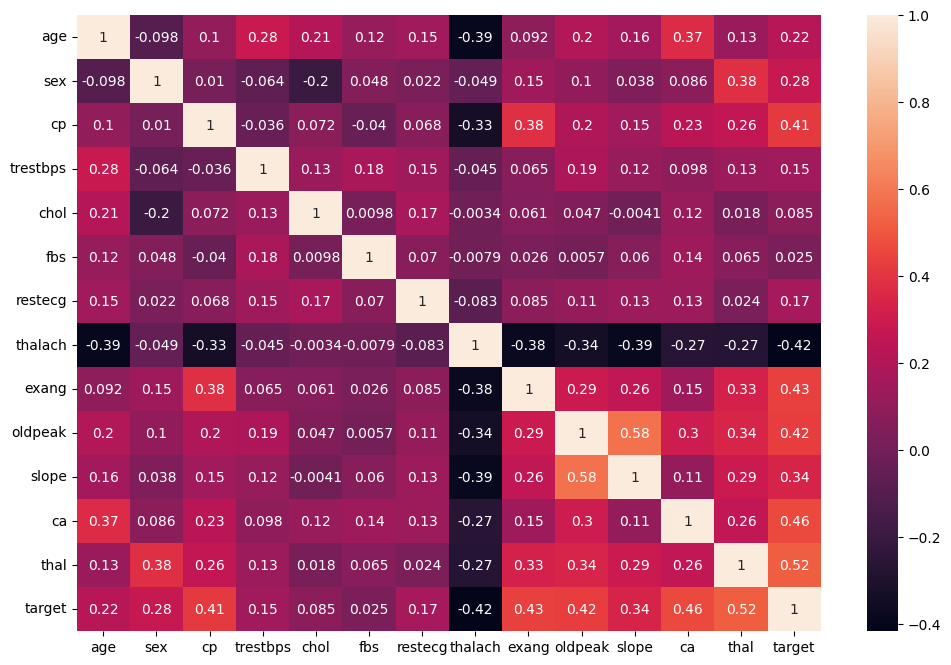

In [18]:
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(),annot=True,)
plt.show()

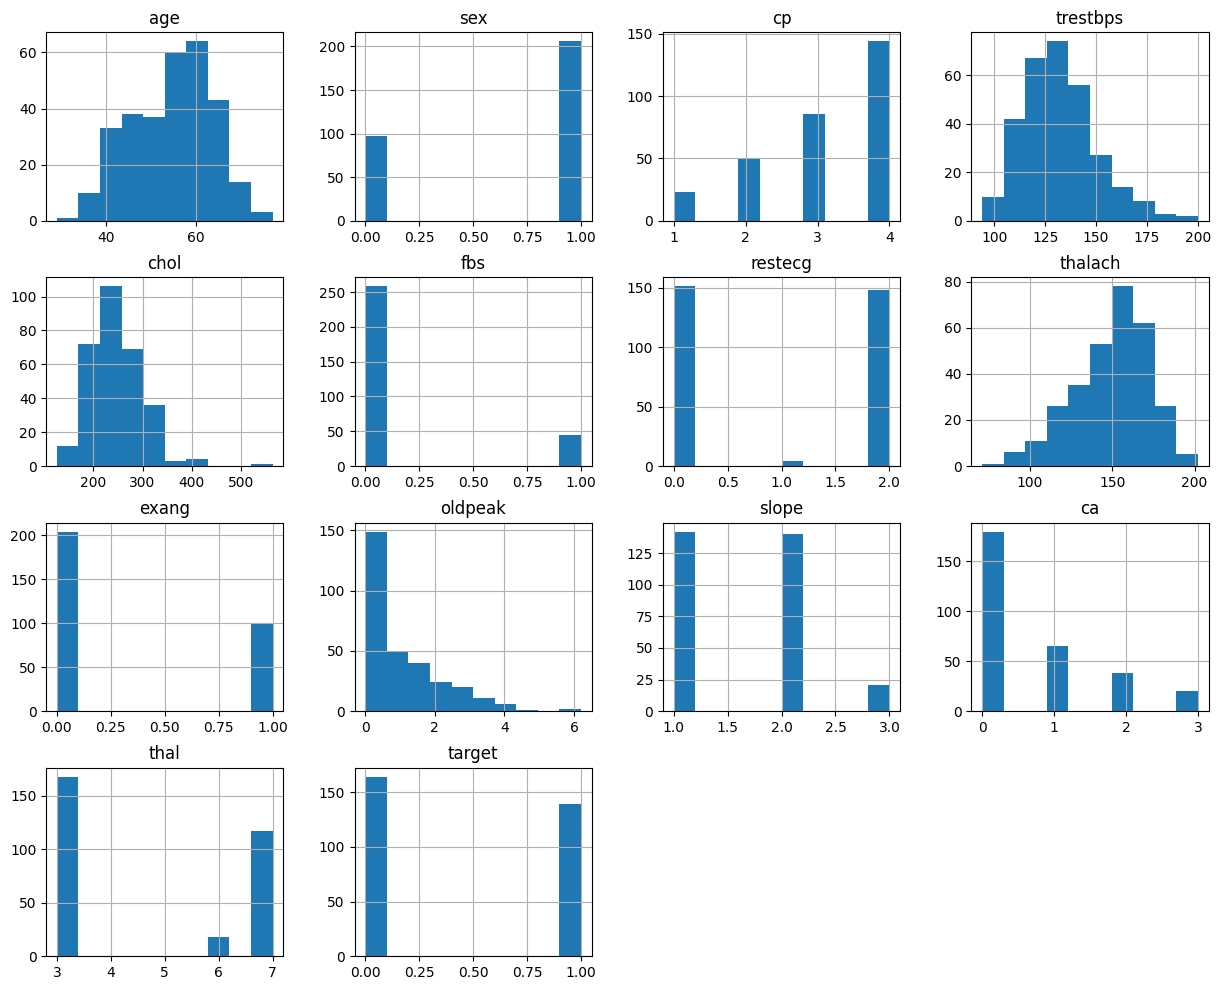

In [19]:
df.hist(figsize=(15,12))
plt.show()

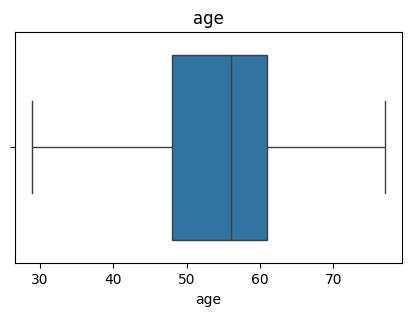

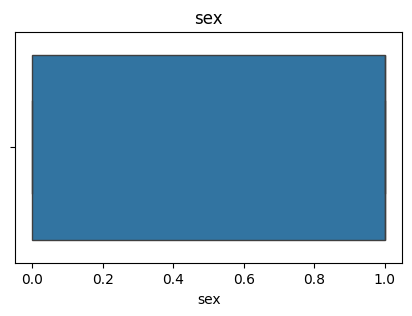

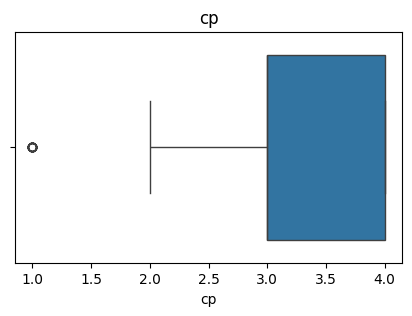

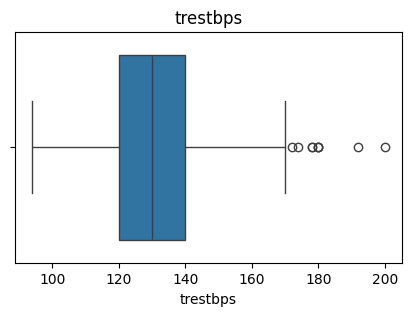

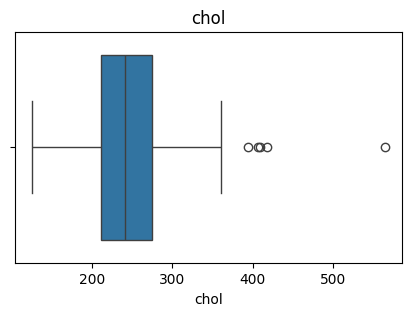

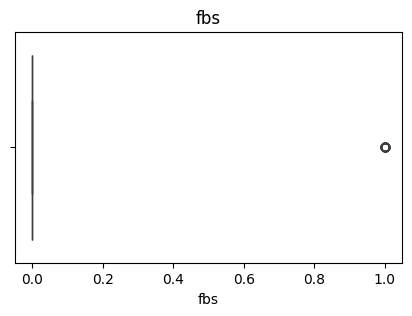

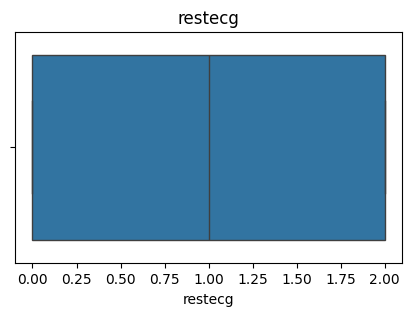

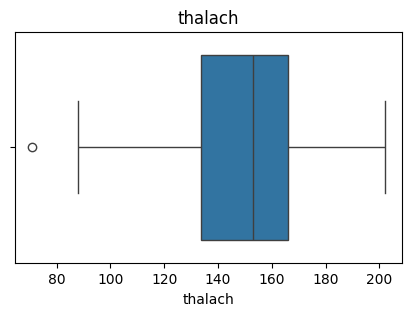

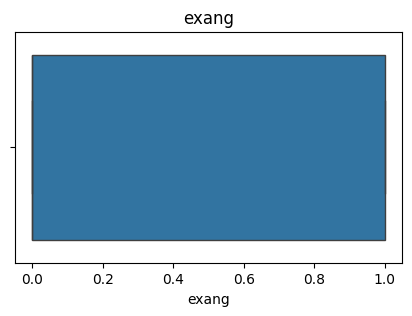

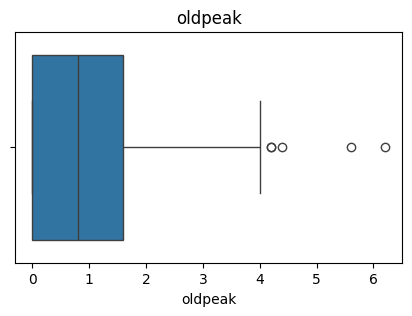

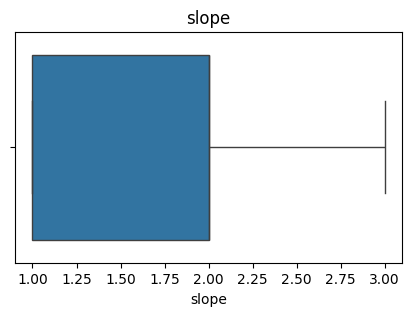

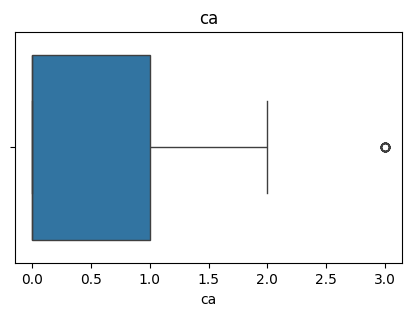

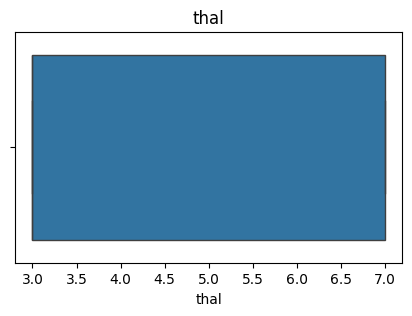

In [20]:
for col in df.columns[:-1]:

    plt.figure(figsize=(5,3))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [21]:
X = df.drop('target', axis=1)
y = df['target']

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [23]:
print(X_train.shape)
print(X_test.shape)

(242, 13)
(61, 13)


In [24]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [25]:
X_train_scaled

array([[-0.72948484,  0.68313005,  0.8701687 , ...,  0.67505958,
        -0.68971531,  1.17997269],
       [ 0.05016647,  0.68313005, -1.18427838, ..., -0.9585846 ,
        -0.68971531, -0.87806977],
       [-0.06121229, -1.46385011, -1.18427838, ..., -0.9585846 ,
         0.44573438, -0.87806977],
       ...,
       [ 1.38671155,  0.68313005,  0.8701687 , ...,  0.67505958,
         1.58118408,  1.17997269],
       [ 1.60946907,  0.68313005, -0.15705484, ...,  0.67505958,
         2.71663377,  1.17997269],
       [-0.72948484,  0.68313005, -1.18427838, ...,  2.30870375,
        -0.68971531,  1.17997269]], shape=(242, 13))

In [26]:
X_test_scaled

array([[ 4.95681494e-01,  6.83130051e-01,  8.70168699e-01,
         4.00391281e-01,  4.01253955e-01, -4.11195970e-01,
         1.02299580e+00,  1.41509977e+00, -6.96177116e-01,
        -8.91627350e-01, -9.58584599e-01, -6.89715311e-01,
        -8.78069766e-01],
       [ 1.27533279e+00,  6.83130051e-01,  8.70168699e-01,
         1.65137906e+00, -4.14104111e-01, -4.11195970e-01,
         1.02299580e+00, -5.28403693e-01, -6.96177116e-01,
         1.16081179e+00, -9.58584599e-01, -6.89715311e-01,
         6.65462074e-01],
       [-3.95348564e-01, -1.46385011e+00, -1.57054838e-01,
        -5.45133669e-02,  1.16826723e-01, -4.11195970e-01,
         1.02299580e+00, -4.25278274e-02, -6.96177116e-01,
        -4.45444929e-01, -9.58584599e-01, -6.89715311e-01,
        -8.78069766e-01],
       [-2.28878744e+00,  6.83130051e-01, -2.21150191e+00,
        -7.36870338e-01, -1.28634762e+00, -4.11195970e-01,
         1.02299580e+00,  1.06173550e+00, -6.96177116e-01,
        -8.91627350e-01, -9.58584599e

In [27]:
# Logistic Regression
clf1 = LogisticRegression(random_state=42)
clf1.fit(X_train_scaled,y_train)
pred1=clf1.predict(X_test_scaled)
prob1=clf1.predict_proba(X_test_scaled)[:,1]

In [28]:
print("Logistic Regression Results")
print("Accuracy :", accuracy_score(y_test, pred1))
print("Precision:", precision_score(y_test, pred1))
print("Recall   :", recall_score(y_test, pred1))
print("F1 Score :", f1_score(y_test, pred1))
print("ROC AUC  :", roc_auc_score(y_test, prob1))

Logistic Regression Results
Accuracy : 0.8688524590163934
Precision: 0.8125
Recall   : 0.9285714285714286
F1 Score : 0.8666666666666667
ROC AUC  : 0.9512987012987013


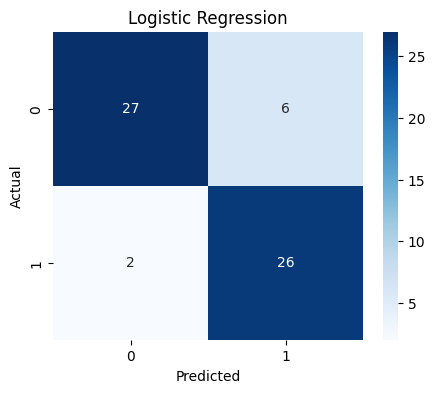

In [29]:
cm = confusion_matrix(y_test, pred1)

plt.figure(figsize=(5,4))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression")
plt.show()

In [31]:
print(classification_report(y_test, pred1))

              precision    recall  f1-score   support

           0       0.93      0.82      0.87        33
           1       0.81      0.93      0.87        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.88      0.87      0.87        61



SVM Model

In [33]:
clf2 = SVC(probability=True,random_state=42)
clf2.fit(X_train_scaled, y_train)
pred2 = clf2.predict(X_test_scaled)
prob2 = clf2.predict_proba(X_test_scaled)[:,1]

In [35]:
print("Support Vector Machine")
print("Accuracy :", accuracy_score(y_test, pred2))
print("Precision:", precision_score(y_test, pred2))
print("Recall   :", recall_score(y_test, pred2))
print("F1 Score :", f1_score(y_test, pred2))
print("ROC AUC  :", roc_auc_score(y_test, prob2))

Support Vector Machine
Accuracy : 0.8524590163934426
Precision: 0.8064516129032258
Recall   : 0.8928571428571429
F1 Score : 0.847457627118644
ROC AUC  : 0.9437229437229437


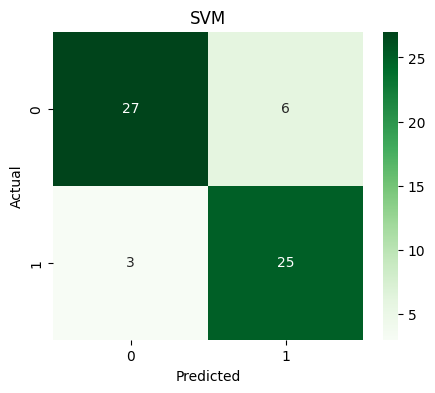

In [36]:
cm = confusion_matrix(y_test, pred2)

plt.figure(figsize=(5,4))
sns.heatmap(cm,annot=True,fmt='d',cmap='Greens')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("SVM")
plt.show()

In [37]:
print(classification_report(y_test, pred2))

              precision    recall  f1-score   support

           0       0.90      0.82      0.86        33
           1       0.81      0.89      0.85        28

    accuracy                           0.85        61
   macro avg       0.85      0.86      0.85        61
weighted avg       0.86      0.85      0.85        61



# Random Forest classifier

In [38]:
clf3=RandomForestClassifier(n_estimators=100,random_state=42)
clf3.fit(X_train_scaled, y_train)
pred3 = clf3.predict(X_test_scaled)
prob3 = clf3.predict_proba(X_test_scaled)[:,1]

In [39]:
print("Random Forest")
print("Accuracy :", accuracy_score(y_test, pred3))
print("Precision:", precision_score(y_test, pred3))
print("Recall   :", recall_score(y_test, pred3))
print("F1 Score :", f1_score(y_test, pred3))
print("ROC AUC  :", roc_auc_score(y_test, prob3))

Random Forest
Accuracy : 0.8852459016393442
Precision: 0.8181818181818182
Recall   : 0.9642857142857143
F1 Score : 0.8852459016393442
ROC AUC  : 0.9512987012987013


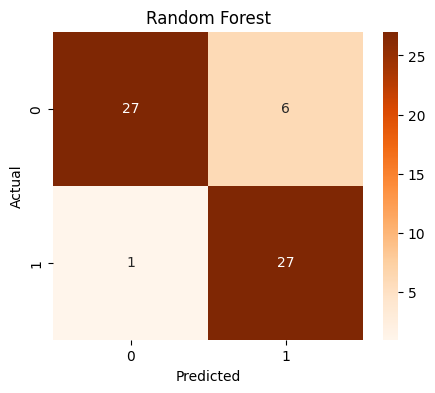

In [40]:
cm = confusion_matrix(y_test, pred3)
plt.figure(figsize=(5,4))
sns.heatmap(cm,annot=True,fmt='d',cmap='Oranges')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest")
plt.show()

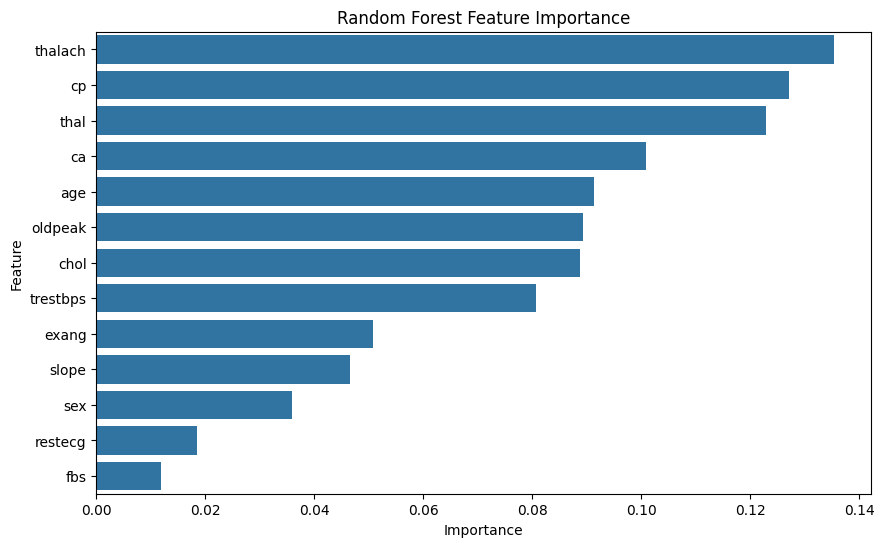

In [41]:
importance = pd.DataFrame({"Feature": X.columns,"Importance": clf3.feature_importances_})

importance = importance.sort_values(by="Importance",ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(data=importance,x="Importance",y="Feature")
plt.title("Random Forest Feature Importance")
plt.show()

# XGBoost

In [42]:
clf4 = XGBClassifier(random_state=42,eval_metric='logloss')
clf4.fit(X_train_scaled, y_train)
pred4 = clf4.predict(X_test_scaled)
prob4 = clf4.predict_proba(X_test_scaled)[:,1]

In [43]:
print("XGBoost")
print("Accuracy :", accuracy_score(y_test, pred4))
print("Precision:", precision_score(y_test, pred4))
print("Recall   :", recall_score(y_test, pred4))
print("F1 Score :", f1_score(y_test, pred4))
print("ROC AUC  :", roc_auc_score(y_test, prob4))

XGBoost
Accuracy : 0.8524590163934426
Precision: 0.7878787878787878
Recall   : 0.9285714285714286
F1 Score : 0.8524590163934426
ROC AUC  : 0.9188311688311689


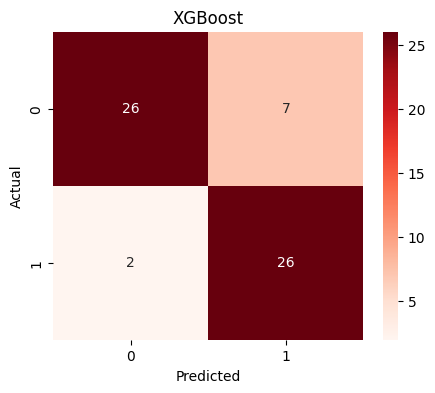

In [44]:
cm = confusion_matrix(y_test, pred4)

plt.figure(figsize=(5,4))
sns.heatmap(cm,annot=True,fmt='d',cmap='Reds')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("XGBoost")
plt.show()

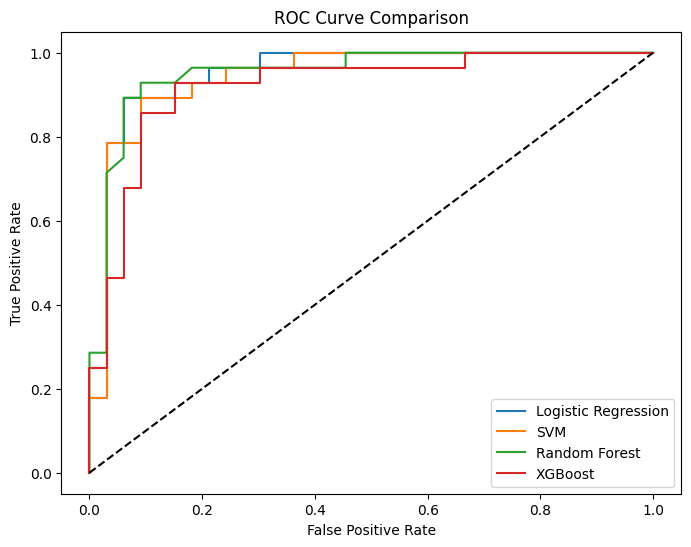

In [46]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(8,6))

models = {
    "Logistic Regression": prob1,
    "SVM": prob2,
    "Random Forest": prob3,
    "XGBoost": prob4
}

for name, prob in models.items():
    fpr, tpr, _ = roc_curve(y_test, prob)
    plt.plot(fpr, tpr, label=name)

plt.plot([0,1], [0,1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

In [47]:
from sklearn.model_selection import GridSearchCV

params = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 5, 10, 15],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

grid = GridSearchCV(RandomForestClassifier(random_state=42),param_grid=params,cv=5,scoring="accuracy",n_jobs=-1)
grid.fit(X_train_scaled, y_train)
print("Best Parameters:", grid.best_params_)
print("Best CV Accuracy:", grid.best_score_)

Best Parameters: {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
Best CV Accuracy: 0.8343537414965987


In [48]:
best_rf = grid.best_estimator_

best_rf.fit(X_train_scaled, y_train)

best_pred = best_rf.predict(X_test_scaled)

best_prob = best_rf.predict_proba(X_test_scaled)[:,1]

print("Final Accuracy:", accuracy_score(y_test, best_pred))
print("Final ROC AUC :", roc_auc_score(y_test, best_prob))

Final Accuracy: 0.9016393442622951
Final ROC AUC : 0.948051948051948


In [64]:
import joblib
joblib.dump(best_rf, "heart_disease_model.pkl")

joblib.dump(scaler, "scaler.pkl")

print("Model Saved Successfully!")

Model Saved Successfully!


In [60]:
def predict_heart_disease(age, sex, cp, trestbps, chol, fbs,
                          restecg, thalach, exang, oldpeak,
                          slope, ca, thal):

    data = pd.DataFrame([{
        "age": age,
        "sex": sex,
        "cp": cp,
        "trestbps": trestbps,
        "chol": chol,
        "fbs": fbs,
        "restecg": restecg,
        "thalach": thalach,
        "exang": exang,
        "oldpeak": oldpeak,
        "slope": slope,
        "ca": ca,
        "thal": thal
    }])

    data_scaled = scaler.transform(data)

    prediction = best_rf.predict(data_scaled)[0]
    probability = best_rf.predict_proba(data_scaled)[0]

    print("Prediction:", prediction)
    print(f"No Disease Probability : {probability[0]*100:.2f}%")
    print(f"Disease Probability    : {probability[1]*100:.2f}%")

    if prediction == 1:
        print("\n❤️ Heart Disease Detected")
    else:
        print("\n✅ No Heart Disease")

In [61]:
predict_heart_disease(
    40, 0, 0, 120, 180,
    0, 0, 175, 0,
    0.0, 2, 0, 2
)

Prediction: 0
No Disease Probability : 94.61%
Disease Probability    : 5.39%

✅ No Heart Disease


In [62]:
predict_heart_disease(
    65, 1, 3, 160, 280,
    1, 2, 120, 1,
    3.5, 0, 2, 3
)

Prediction: 1
No Disease Probability : 34.44%
Disease Probability    : 65.56%

❤️ Heart Disease Detected


In [63]:
import joblib
import pandas as pd

# Load saved model
model = joblib.load("heart_disease_model.pkl")
scaler = joblib.load("scaler.pkl")

sample = pd.DataFrame([{
    "age": 45,
    "sex": 0,
    "cp": 0,
    "trestbps": 120,
    "chol": 180,
    "fbs": 0,
    "restecg": 0,
    "thalach": 170,
    "exang": 0,
    "oldpeak": 0.0,
    "slope": 2,
    "ca": 0,
    "thal": 2
}])

sample_scaled = scaler.transform(sample)

prediction = model.predict(sample_scaled)[0]
probability = model.predict_proba(sample_scaled)[0]

print("Prediction:", prediction)
print(f"Probability (No Disease): {probability[0]:.4f}")
print(f"Probability (Disease): {probability[1]:.4f}")

if prediction == 1:
    print("❤️ Heart Disease Detected")
else:
    print("✅ No Heart Disease")

Prediction: 0
Probability (No Disease): 0.9478
Probability (Disease): 0.0522
✅ No Heart Disease


In [65]:
import sklearn
import scipy

print(np.__version__)
print(pd.__version__)
print(sklearn.__version__)
print(scipy.__version__)

2.4.4
3.0.2
1.8.0
1.16.3


In [66]:
import joblib
print(joblib.__version__)

1.5.3
